In [9]:
import sys
sys.path.append('../')
from core import LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
import numpy as np
from utils import * #only needed for xgboost

from friedman1 import *

iteration 0 complete
iteration 1 complete
iteration 2 complete
iteration 3 complete
iteration 4 complete
iteration 5 complete
iteration 6 complete
iteration 7 complete
iteration 8 complete
iteration 9 complete
iteration 10 complete
iteration 11 complete
iteration 12 complete
iteration 13 complete
iteration 14 complete
iteration 15 complete
iteration 16 complete
iteration 17 complete
iteration 18 complete
iteration 19 complete
iteration 20 complete
iteration 21 complete
iteration 22 complete
iteration 23 complete
iteration 24 complete
iteration 25 complete
iteration 26 complete
iteration 27 complete
iteration 28 complete
iteration 29 complete
iteration 30 complete
iteration 31 complete
iteration 32 complete
iteration 33 complete
iteration 34 complete
iteration 35 complete
iteration 36 complete
iteration 37 complete
iteration 38 complete
iteration 39 complete
iteration 40 complete
iteration 41 complete
iteration 42 complete
iteration 43 complete
iteration 44 complete
iteration 45 complet

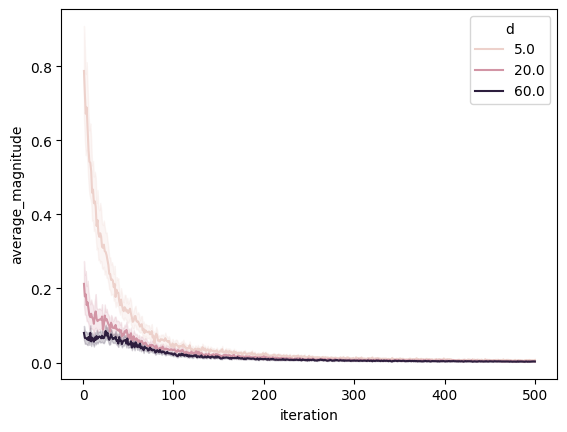

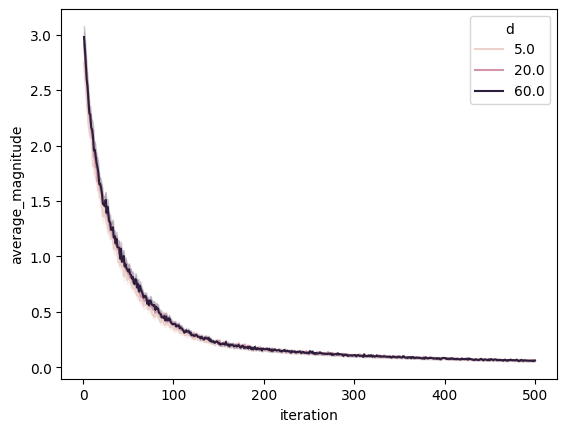

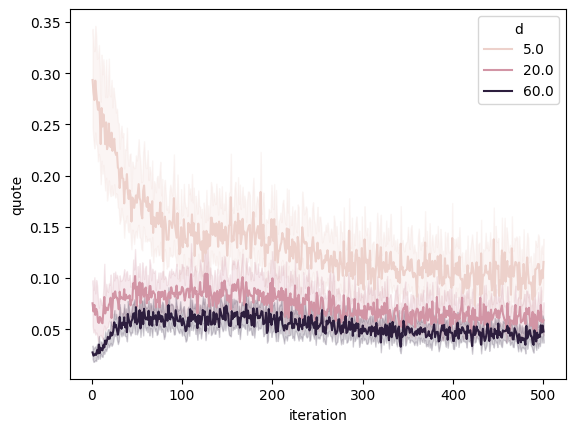

In [10]:
X_target_test, y_target_test = friedman1(n_samples=10000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=1000) #add noise to train set

df_hat = pd.DataFrame(columns = ['iteration', 'average_magnitude', 'd'])
df = pd.DataFrame(columns = ['iteration', 'average_magnitude', 'd'])
for d in [5, 20, 60]:
    for i in range(50):

        X_target_train, y_target_train = friedman1(n_samples=300, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=i) #add noise to train set
        X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = False, noise_distribution = 'gaussian',
                                                            n_features=10, d=d, shift_seed=i, random_seed = i+1)

        #also add noise to source (only train here)

        average_magnitude_hat = []
        average_magnitude = []

        fiter = LSTransferTreeBoost(epochs=500, v=0.1, source_tree_size=3, 
                                target_tree_size=3, k=0.0, m_0=0.5)
        leaf_gammas_tray, leaf_gammashats_tray, model_tray_clf, model_tray_clfhat, alpha_tray = fiter.fit(X_target_train, 
                                                                            y_target_train, X_source_train, y_source_train)
        


        iteration = 1
        for gammahats in leaf_gammashats_tray:
            average_magnitude_hat = np.mean([np.abs(elem) for elem in gammahats])
            df_hat.loc[len(df_hat)] = [iteration, average_magnitude_hat, d]
            iteration += 1
        iteration = 1
        for gammas in leaf_gammas_tray:
            average_magnitude = np.mean([np.abs(elem) for elem in gammas])
            df.loc[len(df)] = [iteration, average_magnitude, d]
            iteration += 1

        print(f'iteration {i} complete')

import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data = df_hat, x = 'iteration', y = 'average_magnitude', hue = 'd')
plt.show()
sns.lineplot(data = df, x = 'iteration', y = 'average_magnitude', hue = 'd')
plt.show()
df_hat['quote'] = df_hat['average_magnitude'] / df['average_magnitude']
sns.lineplot(data = df_hat, x = 'iteration', y = 'quote', hue = 'd')
plt.show()

iteration 0 complete
iteration 1 complete
iteration 2 complete
iteration 3 complete
iteration 4 complete
iteration 5 complete
iteration 6 complete
iteration 7 complete
iteration 8 complete
iteration 9 complete
iteration 10 complete
iteration 11 complete
iteration 12 complete
iteration 13 complete
iteration 14 complete
iteration 15 complete
iteration 16 complete
iteration 17 complete
iteration 18 complete
iteration 19 complete
iteration 20 complete
iteration 21 complete
iteration 22 complete
iteration 23 complete
iteration 24 complete
iteration 25 complete
iteration 26 complete
iteration 27 complete
iteration 28 complete
iteration 29 complete
iteration 30 complete
iteration 31 complete
iteration 32 complete
iteration 33 complete
iteration 34 complete
iteration 35 complete
iteration 36 complete
iteration 37 complete
iteration 38 complete
iteration 39 complete
iteration 40 complete
iteration 41 complete
iteration 42 complete
iteration 43 complete
iteration 44 complete
iteration 45 complet

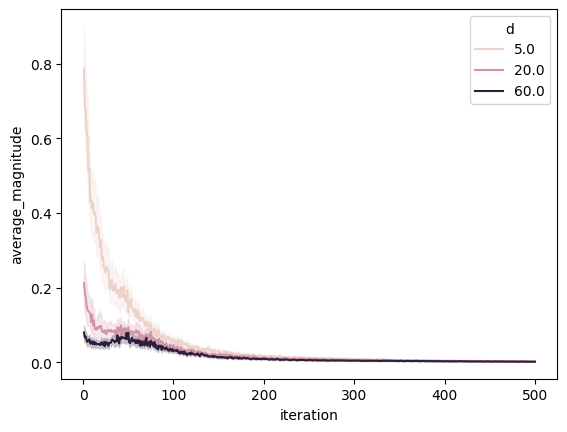

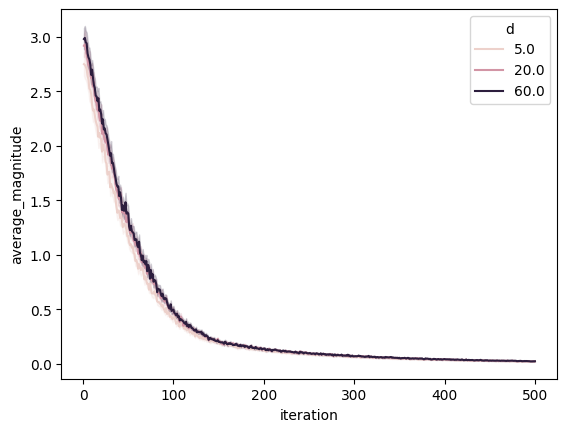

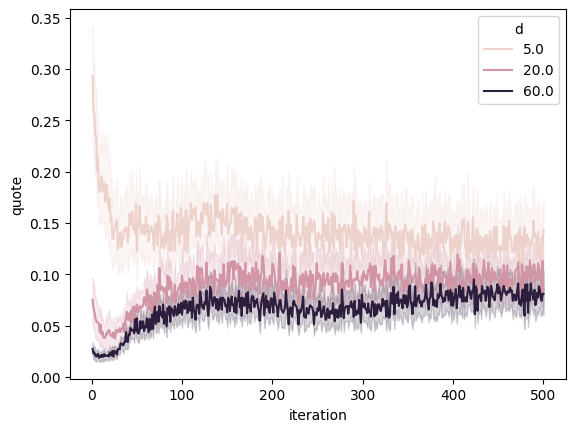

In [11]:
df_hat = pd.DataFrame(columns = ['iteration', 'average_magnitude', 'd'])
df = pd.DataFrame(columns = ['iteration', 'average_magnitude', 'd'])
for d in [5, 20, 60]:
    for i in range(50):

        X_target_train, y_target_train = friedman1(n_samples=300, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=i) #add noise to train set
        X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = False, noise_distribution = 'gaussian',
                                                            n_features=10, d=d, shift_seed=i, random_seed = i+1)

        #also add noise to source (only train here)

        average_magnitude_hat = []
        average_magnitude = []

        fiter = LSTransferTreeBoost(epochs=500, v=0.1, source_tree_size=3, 
                                target_tree_size=3, k=0.01, m_0=0.9)
        leaf_gammas_tray, leaf_gammashats_tray, model_tray_clf, model_tray_clfhat, alpha_tray = fiter.fit(X_target_train, 
                                                                            y_target_train, X_source_train, y_source_train)
        


        iteration = 1
        for gammahats in leaf_gammashats_tray:
            average_magnitude_hat = np.mean([np.abs(elem) for elem in gammahats])
            df_hat.loc[len(df_hat)] = [iteration, average_magnitude_hat, d]
            iteration += 1
        iteration = 1
        for gammas in leaf_gammas_tray:
            average_magnitude = np.mean([np.abs(elem) for elem in gammas])
            df.loc[len(df)] = [iteration, average_magnitude, d]
            iteration += 1

        print(f'iteration {i} complete')

import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data = df_hat, x = 'iteration', y = 'average_magnitude', hue = 'd')
plt.show()
sns.lineplot(data = df, x = 'iteration', y = 'average_magnitude', hue = 'd')
plt.show()
df_hat['quote'] = df_hat['average_magnitude'] / df['average_magnitude']
sns.lineplot(data = df_hat, x = 'iteration', y = 'quote', hue = 'd')
plt.show()